
# Solver benchmarks: Robertson problem

This notebook benchmarks standard ODE solvers on the **Robertson chemical kinetics problem**, a classical **stiff** system.

Here the vector field is known analytically, and the goal is to compare solver behavior on a stiff benchmark.

## The system

The Robertson problem is typically written as
\[
\begin{aligned}
\dot y_1 &= -0.04 y_1 + 10^4 y_2 y_3, \\
\dot y_2 &= 0.04 y_1 - 10^4 y_2 y_3 - 3\times 10^7 y_2^2, \\
\dot y_3 &= 3\times 10^7 y_2^2,
\end{aligned}
\]
with initial condition
\[
y_1(0)=1,\qquad y_2(0)=0,\qquad y_3(0)=0.
\]


Robertson is the **clearly stiff benchmark**


In [14]:

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp



## Experiment parameters

The time interval matters a lot for Robertson because the dynamics evolve on very different time scales.

A good default is to work on a logarithmically wide interval, for example up to `T1 = 1e5`.


In [15]:

# ----------------------------
# User-adjustable parameters
# ----------------------------
T0 = 0.0
T1 = 1e2  

Y0 = np.array([1.0, 0.0, 0.0], dtype=np.float64)

# Common comparison grid. We use a log-like grid away from zero so that
# both fast initial transients and long-time behavior are visible.
N_REF = 4000
T_EVAL = np.concatenate((
    np.array([0.0]),
    np.logspace(-6, np.log10(T1), N_REF - 1)
))

SOLVERS = ["Radau", "BDF", "LSODA"]

# Benchmark tolerances for the candidate solvers
RTOL = 1e-6
ATOL = 1e-10

# Tight tolerances for the reference solution
REF_METHOD = "Radau"
REF_RTOL = 1e-12
REF_ATOL = 1e-14

RESULTS_DIR = Path("results/solver_benchmarks/robertson")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)



## Define the Robertson system

In [16]:
def robertson(t, y):
    y1, y2, y3 = y
    return np.array([
        -0.04 * y1 + 1.0e4 * y2 * y3,
         0.04 * y1 - 1.0e4 * y2 * y3 - 3.0e7 * y2**2,
         3.0e7 * y2**2,
    ], dtype=np.float64)

def robertson_jac(t, y):
    y1, y2, y3 = y
    return np.array([
        [-0.04,               1.0e4 * y3,            1.0e4 * y2],
        [ 0.04,  -1.0e4 * y3 - 6.0e7 * y2,          -1.0e4 * y2],
        [ 0.0,                6.0e7 * y2,            0.0],
    ], dtype=np.float64)

def solve_system(method, rtol, atol, dense_output=False):
    kwargs = {}
    if method in {"Radau", "BDF"}:
        kwargs["jac"] = robertson_jac

    start = time.perf_counter()
    sol = solve_ivp(
        fun=robertson,
        t_span=(T0, T1),
        y0=Y0,
        method=method,
        rtol=rtol,
        atol=atol,
        dense_output=dense_output,
        **kwargs,
    )
    elapsed = time.perf_counter() - start
    return sol, elapsed


## Compute a high-accuracy reference solution

In [17]:

ref_sol, ref_time = solve_system(REF_METHOD, REF_RTOL, REF_ATOL, dense_output=True)

if not ref_sol.success:
    raise RuntimeError(f"Reference solve failed: {ref_sol.message}")

y_ref = ref_sol.sol(T_EVAL)

print(f"Reference method: {REF_METHOD}")
print(f"Reference runtime: {ref_time:.4f} s")
print(f"Reference NFE: {ref_sol.nfev}")
print(f"Reference accepted steps: {len(ref_sol.t) - 1}")


Reference method: Radau
Reference runtime: 0.1589 s
Reference NFE: 13234
Reference accepted steps: 1880



## Plot the reference solution

Because the problem spans very different time scales, we use a **logarithmic time axis** for visualization.


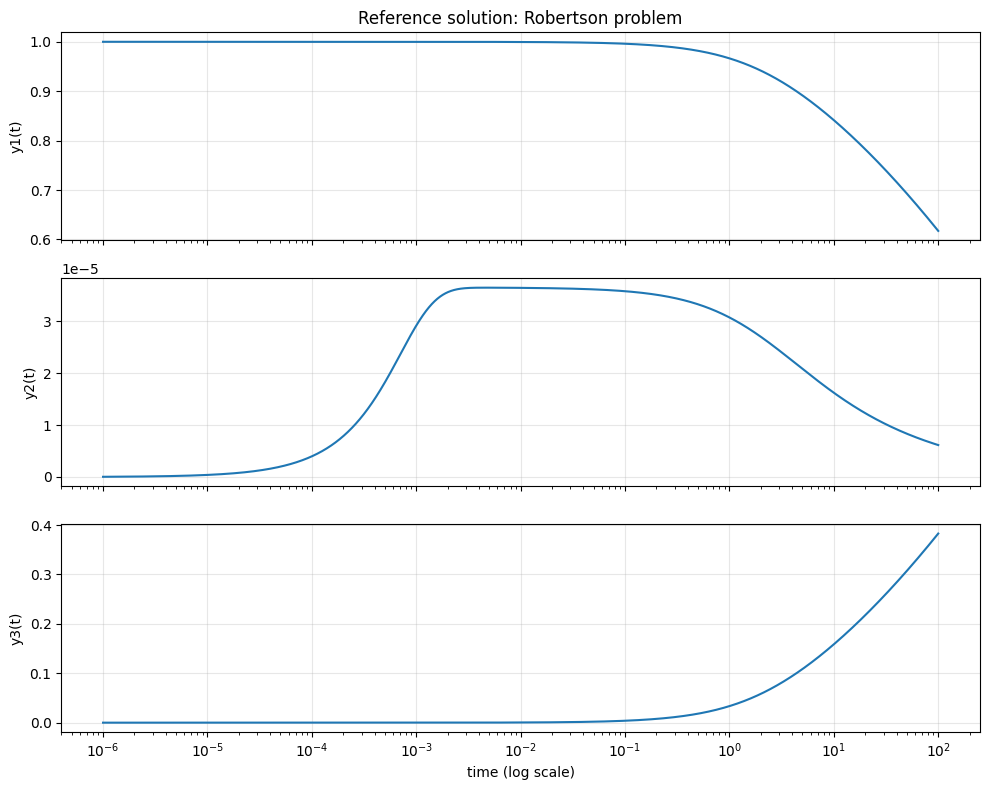

In [18]:

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

labels = ["y1(t)", "y2(t)", "y3(t)"]
for i in range(3):
    axes[i].plot(T_EVAL[1:], y_ref[i, 1:])  # skip t=0 for log axis
    axes[i].set_xscale("log")
    axes[i].set_ylabel(labels[i])
    axes[i].grid(True, alpha=0.3)

axes[0].set_title("Reference solution: Robertson problem")
axes[-1].set_xlabel("time (log scale)")

plt.tight_layout()
plt.show()



## Benchmark the candidate solvers

We compare each solver to the reference trajectory on the common grid `T_EVAL`.

### Metrics
- **runtime_sec**: wall-clock runtime,
- **nfev**: number of function evaluations,
- **accepted_steps**: number of accepted mesh intervals,
- **max_abs_err**: max absolute trajectory error over the reference grid,
- **rmse**: root mean squared trajectory error,
- **rel_l2_err**: relative \(L^2\)-type error over the sampled grid.


In [19]:

def compute_errors(y_num, y_ref):
    diff = y_num - y_ref
    max_abs_err = np.max(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))
    rel_l2_err = np.linalg.norm(diff) / np.linalg.norm(y_ref)
    return max_abs_err, rmse, rel_l2_err

results = []
solutions = {}

for method in SOLVERS:
    try:
        sol, elapsed = solve_system(method, RTOL, ATOL, dense_output=True)
    except Exception as e:
        print(f"{method} raised an exception: {e}")
        continue

    if not sol.success:
        print(f"{method} failed: {sol.message}")
        continue

    y_num = sol.sol(T_EVAL)
    max_abs_err, rmse, rel_l2_err = compute_errors(y_num, y_ref)

    step_sizes = np.diff(sol.t)
    solutions[method] = {
        "sol": sol,
        "elapsed": elapsed,
        "y_num": y_num,
        "step_sizes": step_sizes,
    }

    results.append(
        {
            "solver": method,
            "runtime_sec": elapsed,
            "nfev": sol.nfev,
            "njev": getattr(sol, "njev", np.nan),
            "nlu": getattr(sol, "nlu", np.nan),
            "accepted_steps": len(sol.t) - 1,
            "min_step": np.min(step_sizes) if len(step_sizes) > 0 else np.nan,
            "max_step": np.max(step_sizes) if len(step_sizes) > 0 else np.nan,
            "mean_step": np.mean(step_sizes) if len(step_sizes) > 0 else np.nan,
            "max_abs_err": max_abs_err,
            "rmse": rmse,
            "rel_l2_err": rel_l2_err,
            "status": sol.status,
            "message": sol.message,
        }
    )

results_df = pd.DataFrame(results).sort_values(["rel_l2_err", "runtime_sec"]).reset_index(drop=True)
results_df



,solver,runtime_sec,nfev,njev,nlu,accepted_steps,min_step,max_step,mean_step,max_abs_err,rmse,rel_l2_err,status,message
0,Radau,0.020490,726,22,110,88,0.000078,8.234339,1.136364,4.832095e-08,4.947155e-09,8.889134e-09,0,The solver successfully reached the end of the...
1,LSODA,0.004453,496,35,35,240,0.000002,3.151608,0.416667,6.867540e-07,7.656715e-08,1.375772e-07,0,The solver successfully reached the end of the...
2,BDF,0.011872,431,5,37,163,0.000001,4.292389,0.613497,7.096667e-07,1.566077e-07,2.813954e-07,0,The solver successfully reached the end of the...


## Save the benchmark table

In [20]:

results_csv = RESULTS_DIR / "benchmark_results.csv"
results_df.to_csv(results_csv, index=False)

## Trajectory overlays against the reference solution

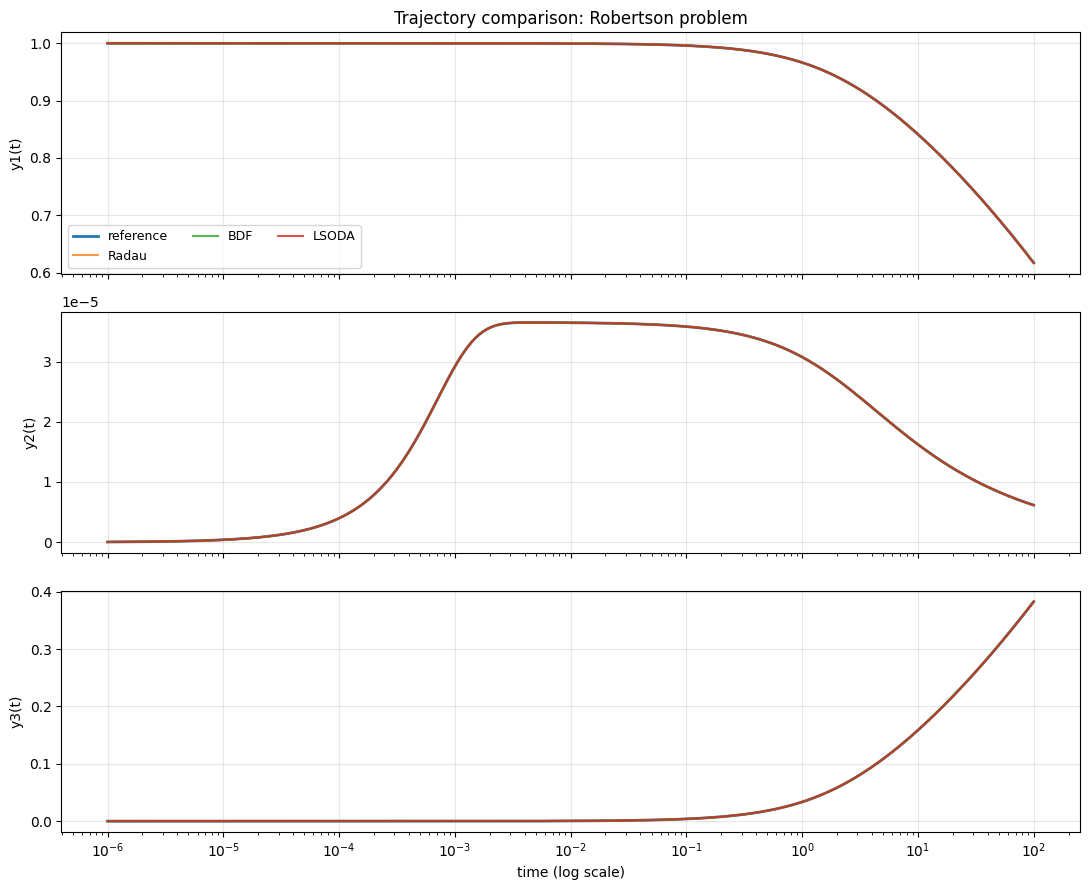

In [21]:

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

labels = ["y1(t)", "y2(t)", "y3(t)"]

for i in range(3):
    axes[i].plot(T_EVAL[1:], y_ref[i, 1:], linewidth=2, label="reference")
    for method, payload in solutions.items():
        y_num = payload["y_num"]
        axes[i].plot(T_EVAL[1:], y_num[i, 1:], alpha=0.8, label=method)
    axes[i].set_xscale("log")
    axes[i].set_ylabel(labels[i])
    axes[i].grid(True, alpha=0.3)

axes[0].set_title("Trajectory comparison: Robertson problem")
axes[0].legend(ncol=3, fontsize=9)
axes[-1].set_xlabel("time (log scale)")

plt.tight_layout()
traj_path = RESULTS_DIR / "trajectory_overlay.png"
plt.savefig(traj_path, dpi=200, bbox_inches="tight")
plt.show()


## Error vs NFE

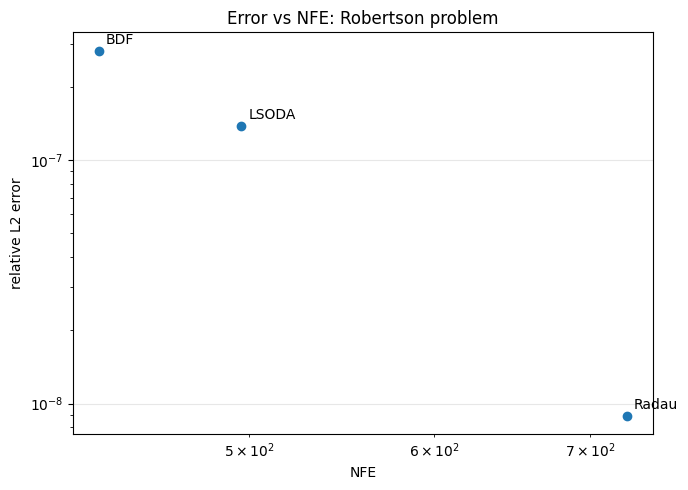

In [22]:

plt.figure(figsize=(7, 5))
plt.scatter(results_df["nfev"], results_df["rel_l2_err"])

for _, row in results_df.iterrows():
    plt.annotate(row["solver"], (row["nfev"], row["rel_l2_err"]), xytext=(5, 5), textcoords="offset points")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("NFE")
plt.ylabel("relative L2 error")
plt.title("Error vs NFE: Robertson problem")
plt.grid(True, alpha=0.3)
plt.tight_layout()

path = RESULTS_DIR / "error_vs_nfe.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()


## Error vs runtime

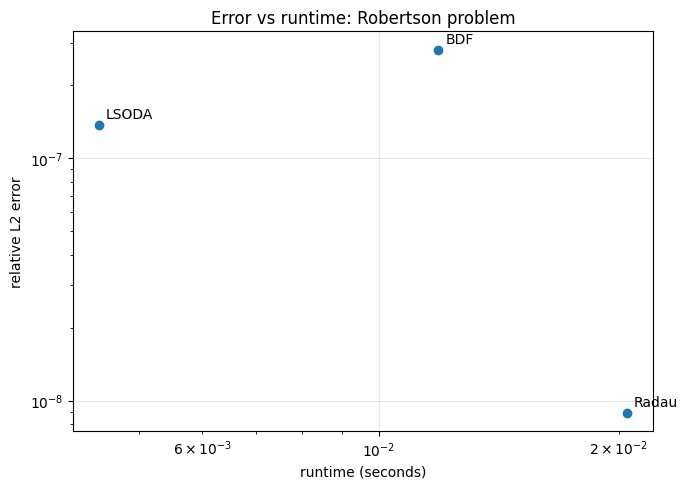

In [23]:

plt.figure(figsize=(7, 5))
plt.scatter(results_df["runtime_sec"], results_df["rel_l2_err"])

for _, row in results_df.iterrows():
    plt.annotate(row["solver"], (row["runtime_sec"], row["rel_l2_err"]), xytext=(5, 5), textcoords="offset points")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("runtime (seconds)")
plt.ylabel("relative L2 error")
plt.title("Error vs runtime: Robertson problem")
plt.grid(True, alpha=0.3)
plt.tight_layout()

path = RESULTS_DIR / "error_vs_runtime.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()


## Accepted step sizes

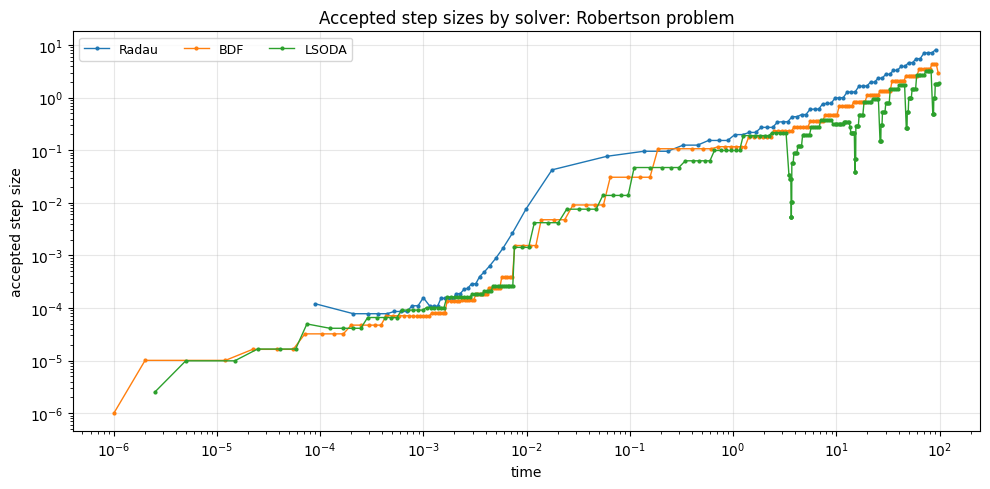

In [24]:

plt.figure(figsize=(10, 5))

for method, payload in solutions.items():
    sol = payload["sol"]
    step_sizes = payload["step_sizes"]
    if len(step_sizes) > 0:
        mask_t = sol.t[:-1] > 0
        if np.any(mask_t):
            plt.plot(sol.t[:-1][mask_t], step_sizes[mask_t], marker="o", markersize=2, linewidth=1, label=method)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("time")
plt.ylabel("accepted step size")
plt.title("Accepted step sizes by solver: Robertson problem")
plt.grid(True, alpha=0.3)
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()

path = RESULTS_DIR / "accepted_step_sizes.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
